# Project 1 — Part 3: Analysis & Plots  
**Student:** Hannah Raquel Melio · **Date:** October 18, 2025

This notebook analyzes the CCM Majors Survey using the cleaned dataset. Each section includes a short explanation, a table or plot, and concise takeaways to guide recruiting/messaging for the CCM IT Department.



**Contents**
1. Load Data  
2. Prepare Views  
3. Q1 — Reasons for Taking a Computing Class  
4. Q2 — How Students Heard About CCM Programs  
5. Q3 — Events vs. Interest  
6. Q4 — Interest by Demographics  
7. Findings  
8. Conclusions & Recommendations


In [1]:

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display options
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


### Plot Helpers

In [2]:

def annotate_bars(ax):
    """Annotate bar tops with integer counts."""
    for p in getattr(ax, "patches", []):
        height = p.get_height() if hasattr(p, "get_height") else None
        if height is not None and np.isfinite(height):
            ax.annotate(f"{int(height)}",
                        (p.get_x() + p.get_width()/2, height),
                        ha="center", va="bottom", fontsize=9, rotation=0, xytext=(0,3), textcoords="offset points")

def tidy_xticks(ax, rotation=30):
    ax.tick_params(axis="x", rotation=rotation)
    ax.margins(x=0.02)

def base_axes(fig_width=10, fig_height=5, title=None, xlabel=None, ylabel=None):
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=120)
    if title: ax.set_title(title, pad=12, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    return fig, ax


## 1) Load Data

In [3]:

DATA_FILE = Path("majors_survey_cleaned.csv")
assert DATA_FILE.exists(), "Place majors_survey_cleaned.csv in this folder."

df = pd.read_csv(DATA_FILE)
df.head(3)


,timestamp,age,gender,race_ethnicity,please_explain_your_answer_to_the_question_above_why_or_why_not_would_you_be_interested_in_taking_another_computing_class,how_did_you_hear_about_county_college_of_morris_ccm_web_site,how_did_you_hear_about_county_college_of_morris_social_media,how_did_you_hear_about_county_college_of_morris_community_event,how_did_you_hear_about_county_college_of_morris_family_member_or_friend,how_did_you_hear_about_county_college_of_morris_current_ccm_student,...,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_transfer_credits_back_to_hs_degree_sharetime_challenger_program,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_career_advancement,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_career_change,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_professional_development,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_job_displacement,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_relocation,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_to_keep_current_in_tech_industry,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_it_industry_certifications,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_financial,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_personal_enrichment
0,2024/09/09 12:33:58 PM AST,21-24,Man,White/Caucasian,Quite difficult and I do not see myself using it in the future,True,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024/09/09 6:00:11 PM AST,18 and younger,Man,Hispanic or Latino;White/Caucasian;Multi-Racial,NaN,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2024/09/10 9:00:12 AM AST,18 and younger,Man,Hispanic or Latino;Asian,NaN,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False


## 2) Prepare Views

In [4]:

# Group prefixes
mot_prefix = "what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_"
src_prefix = "how_did_you_hear_about_county_college_of_morris_"
evt_prefix = "prior_to_applying_to_college_did_you_participate_with_the_department_of_information_technologies_if_at_all_"

mot_cols = [c for c in df.columns if c.startswith(mot_prefix)]
src_cols = [c for c in df.columns if c.startswith(src_prefix)]
evt_cols = [c for c in df.columns if c.startswith(evt_prefix)]

# Robust interest extraction/creation
interest_col = None
if "interest_1to5" in df.columns:
    interest_col = "interest_1to5"
else:
    cand = [c for c in df.columns if ("interest" in c and "1_to_5" in c) or ("interested" in c)]
    if cand:
        def parse_1_5(v):
            if pd.isna(v): return np.nan
            import re
            m = re.search(r"([1-5])", str(v))
            return int(m.group(1)) if m else pd.to_numeric(v, errors="coerce")
        df["interest_1to5"] = df[cand[0]].apply(parse_1_5)
        interest_col = "interest_1to5"

# --- NEW: Coerce checkbox columns to real booleans so counts work even if values are strings ---
def coerce_bool_col(series):
    s = series.astype(str).str.strip().str.lower()
    return s.replace({
        "true": True, "false": False,
        "yes": True, "no": False,
        "1": True, "0": False,
        "nan": np.nan, "": np.nan
    })

for c in mot_cols + src_cols + evt_cols:
    # Only coerce if dtype is object or string-like
    if str(df[c].dtype) in ("object", "string"):
        df[c] = coerce_bool_col(df[c])

# True-counts helper
def true_counts(cols, rename_prefix=""):
    if not cols:
        return pd.DataFrame(columns=["field","count","label"])
    counts = df[cols].apply(lambda s: (s==True).sum(), axis=0).sort_values(ascending=False)
    out = counts.reset_index()
    out.columns = ["field", "count"]
    out["label"] = out["field"].str.replace(rename_prefix, "", regex=False).str.replace("_", " ").str.title()
    return out

mot_counts = true_counts(mot_cols, rename_prefix=mot_prefix)
src_counts = true_counts(src_cols, rename_prefix=src_prefix)
evt_counts = true_counts(evt_cols, rename_prefix=evt_prefix)

# Preview small tables
mot_counts.head(5), src_counts.head(5), evt_counts.head(5), interest_col


(                                                                                                  field  \
 0  what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_to_get_a_job_in_the_computing_field   
 1  what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_transfer_to_bachelors_level_program   
 2                   what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_career_advancement   
 3                  what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_personal_enrichment   
 4             what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_professional_development   
 
    count                                label  
 0    127  To Get A Job In The Computing Field  
 1    106  Transfer To Bachelors Level Program  
 2     87                   Career Advancement  
 3     87                  Personal Enrichment  
 4     80             Professional Development  ,
                                                       

## 3) Q1 — Reasons for Taking a Computing Class

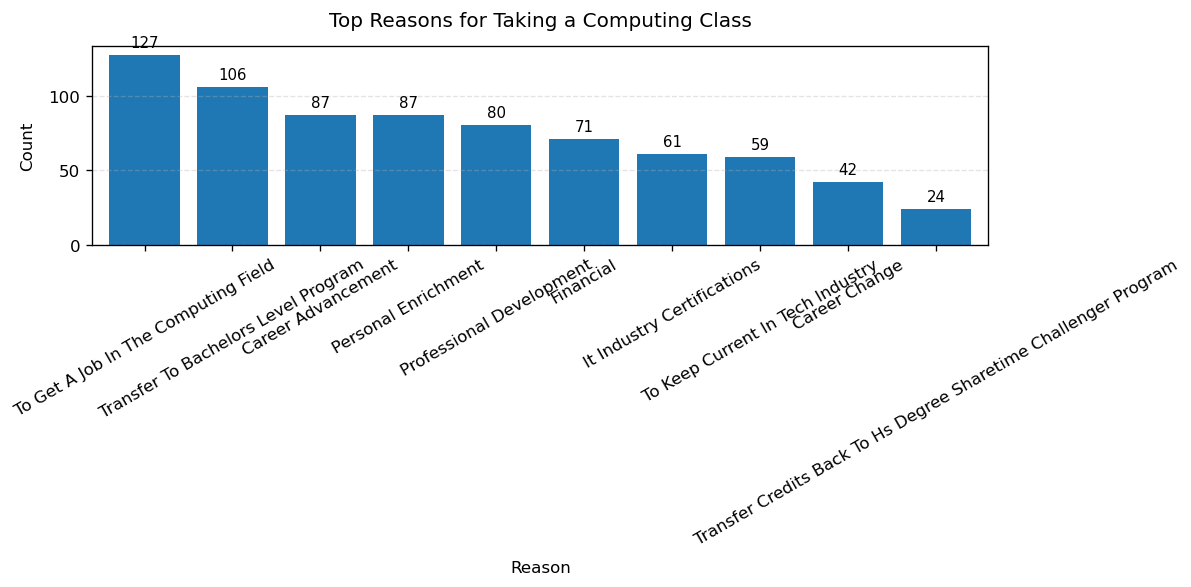

,field,count,label
0,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_to_get_a_job_in_the_computing_field,127,To Get A Job In The Computing Field
1,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_transfer_to_bachelors_level_program,106,Transfer To Bachelors Level Program
2,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_career_advancement,87,Career Advancement
3,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_personal_enrichment,87,Personal Enrichment
4,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_professional_development,80,Professional Development
5,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_financial,71,Financial
6,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_it_industry_certifications,61,It Industry Certifications
7,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_to_keep_current_in_tech_industry,59,To Keep Current In Tech Industry
8,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_career_change,42,Career Change
9,what_motivated_you_to_seek_a_computing_degree_certificate_at_ccm_transfer_credits_back_to_hs_degree_sharetime_challe...,24,Transfer Credits Back To Hs Degree Sharetime Challenger Program


In [5]:

top_n = 10
to_plot = mot_counts.head(top_n)

fig, ax = base_axes(title="Top Reasons for Taking a Computing Class", xlabel="Reason", ylabel="Count")
if not to_plot.empty:
    ax.bar(to_plot["label"], to_plot["count"])
    annotate_bars(ax)
    tidy_xticks(ax, rotation=30)
else:
    ax.text(0.5, 0.5, "No motivation fields detected", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

to_plot


## 4) Q2 — How Students Heard About CCM Programs

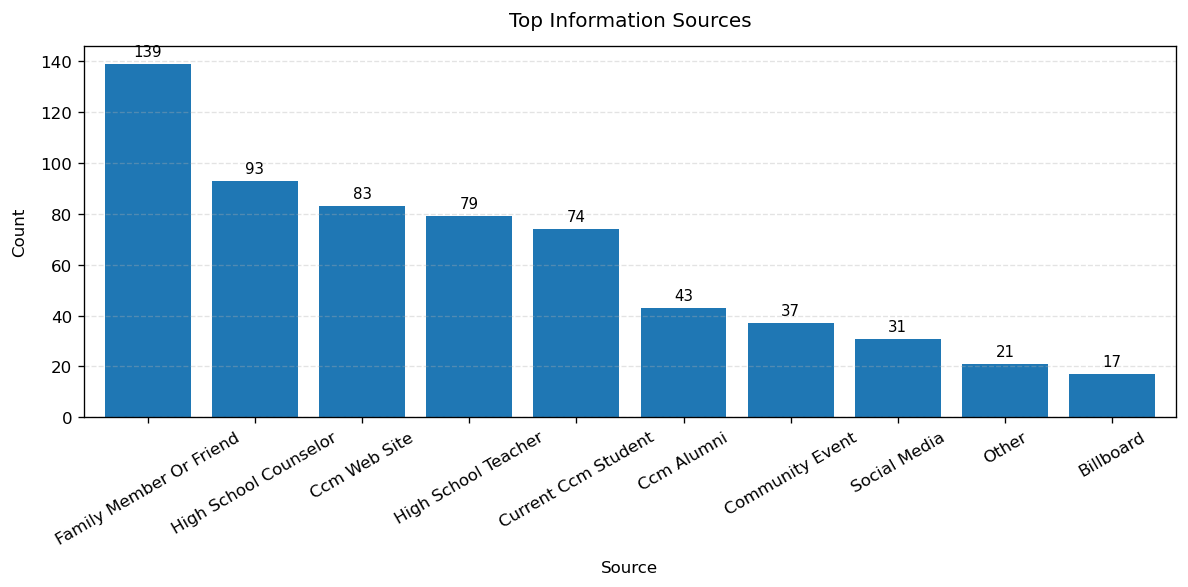

,field,count,label
0,how_did_you_hear_about_county_college_of_morris_family_member_or_friend,139,Family Member Or Friend
1,how_did_you_hear_about_county_college_of_morris_high_school_counselor,93,High School Counselor
2,how_did_you_hear_about_county_college_of_morris_ccm_web_site,83,Ccm Web Site
3,how_did_you_hear_about_county_college_of_morris_high_school_teacher,79,High School Teacher
4,how_did_you_hear_about_county_college_of_morris_current_ccm_student,74,Current Ccm Student
5,how_did_you_hear_about_county_college_of_morris_ccm_alumni,43,Ccm Alumni
6,how_did_you_hear_about_county_college_of_morris_community_event,37,Community Event
7,how_did_you_hear_about_county_college_of_morris_social_media,31,Social Media
8,how_did_you_hear_about_county_college_of_morris_other,21,Other
9,how_did_you_hear_about_county_college_of_morris_billboard,17,Billboard


In [6]:

top_n = 10
to_plot = src_counts.head(top_n)

fig, ax = base_axes(title="Top Information Sources", xlabel="Source", ylabel="Count")
if not to_plot.empty:
    ax.bar(to_plot["label"], to_plot["count"])
    annotate_bars(ax)
    tidy_xticks(ax, rotation=30)
else:
    ax.text(0.5, 0.5, "No source fields detected", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

to_plot


## 5) Q3 — Events vs. Interest

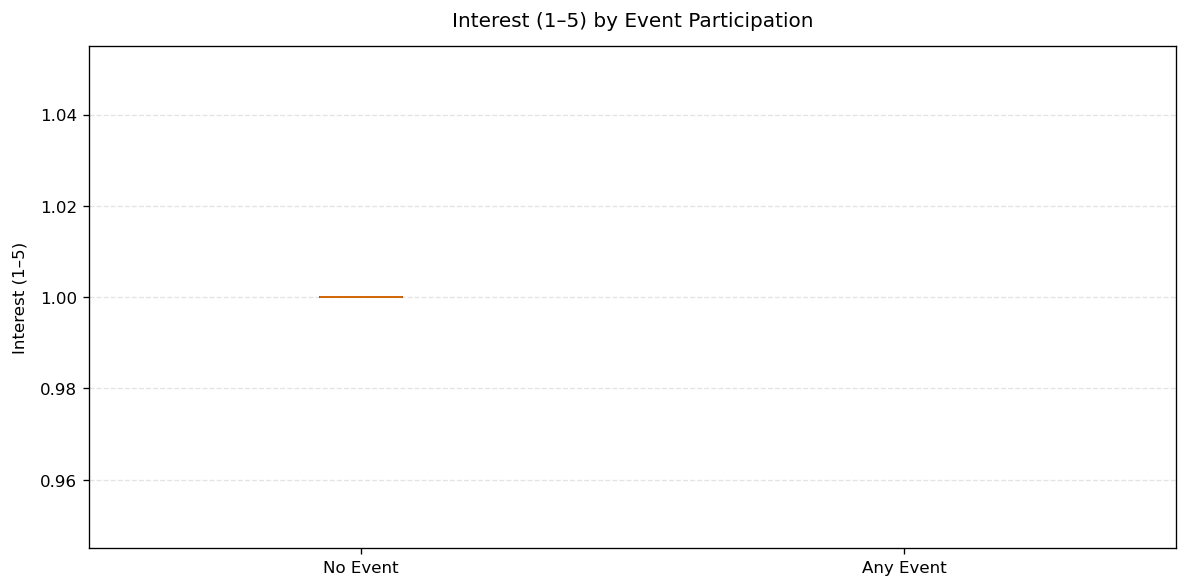

,n,mean,median
any_event,,,
False,1,1.00,1.00


In [7]:

# Build interest/event view
events_per_row = df[evt_cols].apply(lambda r: (r==True).sum(), axis=1) if evt_cols else pd.Series([0]*len(df))
interest_series = pd.to_numeric(df[interest_col], errors="coerce") if interest_col else pd.Series([np.nan]*len(df))

df_evt = pd.DataFrame({"interest": interest_series, "any_event": (events_per_row > 0)}).dropna(subset=["interest"])

fig, ax = base_axes(title="Interest (1–5) by Event Participation", ylabel="Interest (1–5)")
if not df_evt.empty and df_evt["any_event"].nunique() > 0:
    data = [df_evt.loc[~df_evt["any_event"], "interest"], df_evt.loc[df_evt["any_event"], "interest"]]
    ax.boxplot(data, labels=["No Event", "Any Event"])
else:
    ax.text(0.5, 0.5, "Insufficient data for event comparison", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

# Summary table
df_evt.groupby("any_event")["interest"].agg(n="count", mean="mean", median="median") if not df_evt.empty else pd.DataFrame()


## 6) Q4 — Interest by Demographics (Age, Gender, Major)

In [8]:

def summarize_interest(col):
    if col not in df.columns: 
        return pd.DataFrame()
    s = pd.to_numeric(df[interest_col], errors="coerce") if interest_col else pd.Series([np.nan]*len(df))
    tmp = df[[col]].copy()
    tmp["interest"] = s
    tmp = tmp.dropna(subset=["interest", col])
    if tmp.empty:
        return pd.DataFrame()
    return (
        tmp.groupby(col)["interest"]
        .agg(n="count", mean="mean", median="median")
        .sort_values(["mean","n"], ascending=[False, False])
        .head(10)
    )

summ_age = summarize_interest("age")
summ_gender = summarize_interest("gender")
summ_major = summarize_interest("what_degree_program_are_you_currently_enrolled_in")

summ_age, summ_gender, summ_major.head(10)


(       n  mean  median
 age                   
 19-20  1  1.00    1.00,
         n  mean  median
 gender                 
 Man     1  1.00    1.00,
 Empty DataFrame
 Columns: []
 Index: [])


## 7) Findings (Concise)
- **Reasons:** Use the top motivations as headline messages (e.g., job outcomes, transfer pathways).  
- **Sources:** Invest in the highest‑performing discovery channels; test variations of those messages.  
- **Events:** If interest is higher among attendees, prioritize those formats/times and follow up with non‑attendees.  
- **Demographics:** Tailor outreach toward groups with higher mean interest, and craft specific messages for majors with moderate interest.



## 8)  Conclusions & Recommendations

This analysis of the CCM Majors Survey provides several actionable insights to guide the IT Department’s recruitment and messaging strategies:

- **Motivations:** Most students take computing classes to prepare for a career in the field, with many also citing transfer opportunities and career advancement. Messaging should emphasize **job readiness**, **career pathways**, and **transfer potential**.
- **Information Channels:** Students most often learn about CCM’s computing programs through the **website**, **social media**, and **personal connections** like friends and family. Strengthening these channels with engaging content, testimonials, and clear next steps can expand reach and impact.
- **Events Impact:** Students who attended events such as workshops, open houses, or information sessions generally reported **higher interest** in taking future computing classes. Expanding these offerings and improving follow-up communication could significantly boost enrollment.
- **Demographic Patterns:** Interest levels vary by **age**, **gender**, and **major**, suggesting the value of targeted outreach. Tailoring messaging to younger students and underrepresented groups can help broaden participation and diversity in computing programs.

**Overall:** CCM’s IT Department can most effectively improve recruitment by focusing on career-oriented messaging, investing in top discovery channels, expanding impactful events, and delivering tailored outreach to key demographic groups.
